In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [17]:
df = pd.read_csv('IPL Matches 2008-2020.csv',usecols=['result_margin'])

In [18]:
df.head()

,result_margin
0,140.0
1,33.0
2,9.0
3,5.0
4,5.0


In [19]:
df.isnull().mean()*100

result_margin    2.083333
dtype: float64

In [10]:
df['result_margin_99'] = df['result_margin'].fillna(99)
df['result_margin_minus1'] = df['result_margin'].fillna(-1)

In [11]:
print('Original Result_Margin variable variance: ', df['result_margin'].var())
print('Result_Margin Variance after 99 wala imputation: ', df['result_margin_99'].var())
print('Result_Margin Variance after -1 wala imputation: ', df['result_margin_minus1'].var())

Original Result_Margin variable variance:  487.0154579188895
Result_Margin Variance after 99 wala imputation:  613.1147945988201
Result_Margin Variance after -1 wala imputation:  483.71295410802605


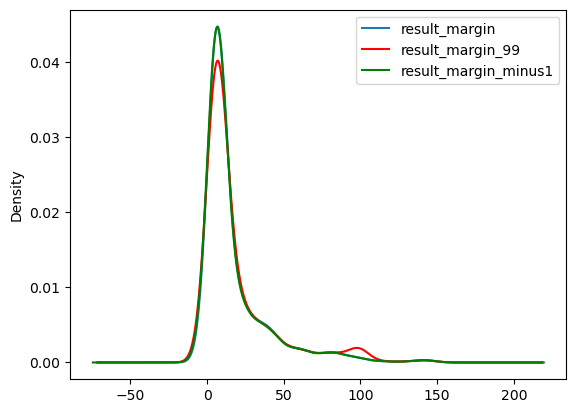

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Variable distribution
df['result_margin'].plot(kind='kde', ax=ax)

# Variable distribution imputed with Arbitrary(99)
df['result_margin_99'].plot(kind='kde', ax=ax, color='red')

# Variable distribution imputed with Arbitrary(-1)
df['result_margin_minus1'].plot(kind='kde', ax=ax, color='green')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

<Axes: >

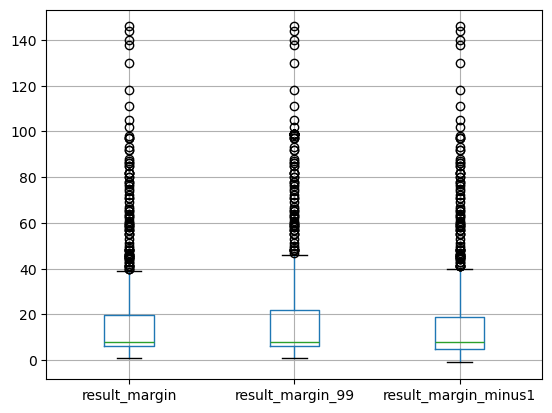

In [15]:
df[['result_margin','result_margin_99','result_margin_minus1']].boxplot()

# using sklearn

In [23]:
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=-1)

In [25]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['result_margin']),
    ('imputer2',imputer2,['result_margin'])
])

In [29]:
trf.fit(df)

ColumnTransformer(transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['result_margin']),
                                ('imputer2',
                                 SimpleImputer(fill_value=-1,
                                               strategy='constant'),
                                 ['result_margin'])])

In [30]:
df = trf.transform(df)

In [31]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [32]:
trf.named_transformers_['imputer2'].statistics_

array([-1.])